In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import requests
import plotly.graph_objects as go

from urllib.parse import urlparse
from functools import lru_cache
from matplotlib.ticker import PercentFormatter
from plotly.subplots import make_subplots
from plotly.colors import qualitative

sys.path.append("../")
from src.repo_utils import RepoStatus

df_paper_assessment = pd.read_parquet("../data/02_paper_assessment/paper_assessment_pred.parquet.br")
df_repo_assessment = pd.read_parquet("../data/03_repo_assessment/references_repo_assessment_pred.parquet.br")

In [2]:
# Join the two dataframes on PMID for analysis

repo_cols = [
    "PMID",
    "repo_content",
    "repo_status",
    "repo_error",
    "is_empty",
    "contains_readme",
    "readme_purpose_and_outputs",
    "contains_requirements",
    "requirements_dependency_versions",
    "contains_license",
    "sufficient_code_documentation",
    "is_modular_and_structured",
    "implements_tests",
    "fixes_seed_if_stochastic",
    "lists_hardware_requirements",
    "contains_link_to_paper",
    "contains_citation",
    "includes_data_or_sample",
    "coding_languages"
]

df_final = df_paper_assessment.merge(
    df_repo_assessment[repo_cols],
    on="PMID",
    how="left",
    validate="one_to_one",  # optional but recommended
)

In [3]:
df_joined = df_paper_assessment.merge(
    df_repo_assessment,
    on="PMID",
    how="left",
    suffixes=("", "_repo")
)

df_inscope = df_final[df_final["is_match"] == True]

## Repo Provider distribution

In [4]:
# --- 1) Clean URLs ---
urls = (
    df_inscope["repo_url"]
    .fillna("")
    .astype(str)
    .str.strip()
)
urls = urls[~urls.isin(["", "Appendix", "Appendi", "<NA>"])]

def _netloc(u: str) -> str:
    if not (u.startswith("http://") or u.startswith("https://")):
        u = "http://" + u
    try:
        return (urlparse(u).netloc or "<invalid>").lower()
    except Exception:
        return "<invalid>"

def _strip_www(netloc: str) -> str:
    netloc = (netloc or "").lower()
    return netloc[4:] if netloc.startswith("www.") else netloc

def _is_doi_netloc(netloc: str) -> bool:
    netloc = _strip_www(netloc)
    return netloc in {"doi.org", "dx.doi.org"}

@lru_cache(maxsize=100_000)
def _resolve_final_url(u: str, timeout: int = 15) -> str | None:
    if not (u.startswith("http://") or u.startswith("https://")):
        u = "https://" + u.lstrip("/")

    try:
        r = requests.head(u, allow_redirects=True, timeout=timeout)
        if r.status_code in (403, 405) or not r.url:
            raise RuntimeError("HEAD not usable")
        return r.url
    except Exception:
        try:
            r = requests.get(u, allow_redirects=True, timeout=timeout)
            return r.url
        except Exception:
            return None

def _final_domain(u: str) -> str:
    raw = _netloc(u)
    if _is_doi_netloc(raw):
        resolved = _resolve_final_url(u)
        if resolved:
            return _netloc(resolved)
    return raw

def _map_provider_domain(netloc: str) -> str:
    """
    Post-process domains into provider buckets.
    Here: merge gitlab.com + self-hosted GitLab instances into 'gitlab'.
    """
    d = _strip_www(netloc)

    # Merge GitLab hosted + self-hosted
    # (covers gitlab.com, *.gitlab.*, and some common self-hosted patterns)
    if "gitlab" in d:
        return "gitlab"

    return d

# --- 2) Correct domain counts (DOI-resolved) + provider mapping ---
final_domains = urls.map(_final_domain).map(_map_provider_domain)

domain_counts = (
    final_domains.value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
    .rename(columns={"index": "domain"})
)

domain_counts.head(n=10).round(3)

,repo_url,proportion
0,github.com,0.837
1,osf.io,0.036
2,zenodo.org,0.034
3,gitlab,0.016
4,figshare.com,0.009
5,codeocean.com,0.007
6,synapse.org,0.004
7,ehealthinformation.ca,0.004
8,pureportal.strath.ac.uk,0.002
9,biostat.app.vumc.org,0.002


## Code Sharing Status

In [5]:
def map_code_sharing_practice(row):
    if not row["is_match"]:
        return None

    status = row["repo_status"]
    repo_empty = row["is_empty"]
    repo_url = row["repo_url"]

    if status == RepoStatus.OK:
        return "Non Empty Repository"
    if status == RepoStatus.EMPTY or repo_empty is True:
        return "Empty Repository"
    if status == RepoStatus.INACCESSIBLE:
        return "Repository Can't Be Accessed"
    if status == RepoStatus.NOT_SUPPORTED:
        return "Repository Provider Not Supported"

    if pd.isna(status) and isinstance(repo_url, str) and repo_url.strip().lower() == "appendix":
        return "Code Shared in Appendix"

    return None


df_final["code_sharing_practice"] = df_final.apply(
    map_code_sharing_practice, axis=1
)

counts = (
    df_final["code_sharing_practice"]
    .dropna()
    .value_counts()
)

total = counts.sum()
summary = counts.astype(str) + " (" + (counts / total * 100).round(1).astype(str) + "%)"

print(f"\nCode sharing practice counts (n={total}):\n")
print(summary.to_string())


Code sharing practice counts (n=522):

code_sharing_practice
Non Empty Repository                 380 (72.8%)
Code Shared in Appendix               75 (14.4%)
Repository Can't Be Accessed           38 (7.3%)
Repository Provider Not Supported      27 (5.2%)
Empty Repository                        2 (0.4%)


In [6]:
# Categories to include
included_practices = {
    "Non Empty Repository",
    "Code Shared in Appendix",
    "Repository Provider Not Supported",
}

# Count papers in those categories
n_selected = (
    df_final["code_sharing_practice"]
    .isin(included_practices)
    .sum()
)

print(f"Number of papers sharing their code: {n_selected}")
print(f"Percentage: {(n_selected / len(df_inscope) * 100).round(1)}%")

Number of papers sharing their code: 482
Percentage: 12.2%


## Code Statement Locations

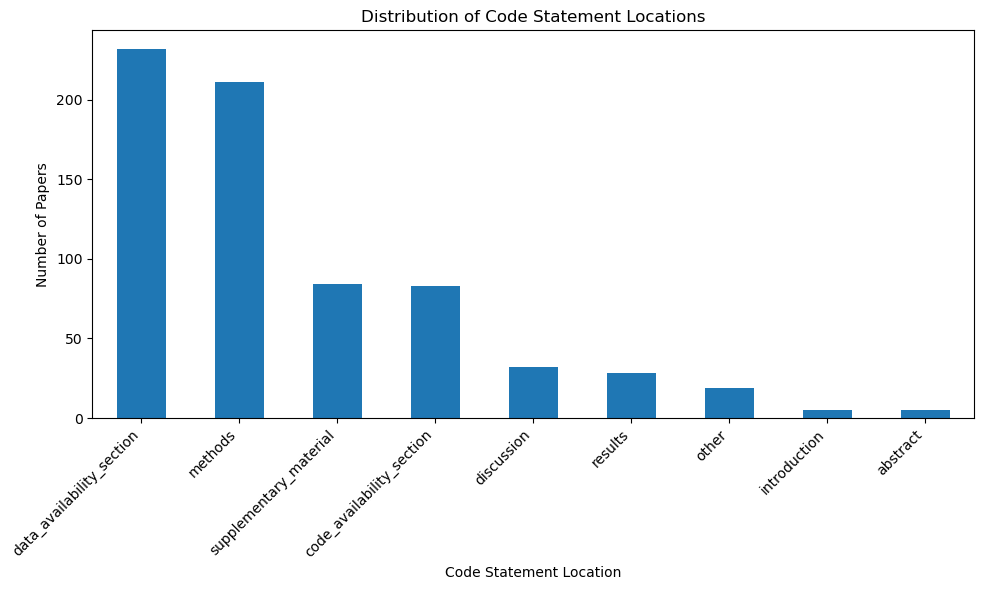

In [7]:
# --- Flatten code_statement_locations ---
locations = (
    df_inscope["code_statement_locations"]
    .dropna()
    .explode()
)

counts = locations.value_counts()

# --- Plot ---
plt.figure(figsize=(10, 6))
counts.plot(kind="bar")
plt.ylabel("Number of Papers")
plt.xlabel("Code Statement Location")
plt.title("Distribution of Code Statement Locations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
counts

code_statement_locations
data_availability_section    232
methods                      211
supplementary_material        84
code_availability_section     83
discussion                    32
results                       28
other                         19
introduction                   5
abstract                       5
Name: count, dtype: int64

In [9]:
n_locations = (
    df_inscope["code_statement_locations"]
    .apply(lambda x: 0 if x is None else len(x))
)

counts = n_locations.value_counts().sort_index()
# Filter to only non-zero counts
counts = counts[counts.index > 0]
total = counts.sum()

summary = (
    counts.astype(str)
    + " ("
    + (counts / total * 100).round(1).astype(str)
    + "%)"
)

print(f"\nNumber of code statement locations per paper (n={total}):\n")
print(summary.to_string())


Number of code statement locations per paper (n=522):

code_statement_locations
1    358 (68.6%)
2    152 (29.1%)
3      11 (2.1%)
4       1 (0.2%)


## Code Statement Sentence

In [10]:
df_inscope["code_statement_sentence"].value_counts(dropna=False)

code_statement_sentence
None                                                                                                            3445
The complete code used for model development and evaluation in this project is publicly available on GitHub:       8
The source code for preprocessing and analyzing the data is available on GitHub                                    3
The code to build and train the model is openly available on github.                                               2
The code used to conduct the analysis is available on GitHub                                                       2
                                                                                                                ... 
All statistical analyses were performed using R software [24]. The R source code is available online at            1
The source code for this study is provided on GitHub                                                               1
The code is in the Source code.zip file.

In [11]:
vc = df_inscope["code_statement_sentence"].value_counts(dropna=False)

repeated = vc[vc >= 2]  # strictly more than 2
print(repeated.to_string())

code_statement_sentence
None                                                                                                            3445
The complete code used for model development and evaluation in this project is publicly available on GitHub:       8
The source code for preprocessing and analyzing the data is available on GitHub                                    3
The code to build and train the model is openly available on github.                                               2
The code used to conduct the analysis is available on GitHub                                                       2
The implementation of the deep learning framework is available at:                                                 2
Code is available at                                                                                               2
The code base for training the deep learning models used in this study is available at:                            2
All code, metadata and documentation for

In [12]:
exactly_once = (vc == 1).sum()

# Calculate proportion

proportion = exactly_once / df_inscope["code_statement_sentence"].notna().sum()

print(f"Proportion of code_statement_sentence that appear exactly once: {proportion:.4f} ({exactly_once}/{df_inscope["code_statement_sentence"].notna().sum()})")

Proportion of code_statement_sentence that appear exactly once: 0.9444 (493/522)


## Code Sharing per Country of Origin

In [13]:
# some names are redundant or inconsistent; normalize them

COUNTRY_NORMALIZATION_MAP = {
    # Netherlands
    "the Netherlands": "Netherlands",
    "The Netherlands": "Netherlands",

    # United States
    "United States of America": "United States",

    # South Korea
    "Republic of Korea": "South Korea",
    "Korea, Republic of": "South Korea",

    # Iran
    "Iran, Islamic Republic of": "Iran",

    # Russia
    "Russian Federation": "Russia",

    # Turkey
    "Türkiye": "Turkey",

    # Optional ISO / spelling harmonization
    "Viet Nam": "Vietnam",
}

def normalize_country(x):
    if x is None:
        return None
    x = str(x).strip()
    if x.lower() == "not reported":
        return None
    return COUNTRY_NORMALIZATION_MAP.get(x, x)


df_inscope["country_first_author_institution_normalized"] = (
    df_inscope["country_first_author_institution"]
    .apply(normalize_country)
)

/var/folders/h6/z36012w55gz3qplddg4wtlf80000gn/T/ipykernel_23171/1429156246.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inscope["country_first_author_institution_normalized"] = (


In [14]:
df_inscope["country_first_author_institution_normalized"].value_counts(normalize=True, dropna=False).round(3)

country_first_author_institution_normalized
China             0.324
United States     0.116
United Kingdom    0.091
Netherlands       0.082
Germany           0.040
                  ...  
Philippines       0.000
Peru              0.000
Zimbabwe          0.000
Egypt             0.000
Uganda            0.000
Name: proportion, Length: 77, dtype: float64

/var/folders/h6/z36012w55gz3qplddg4wtlf80000gn/T/ipykernel_23171/1550960597.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


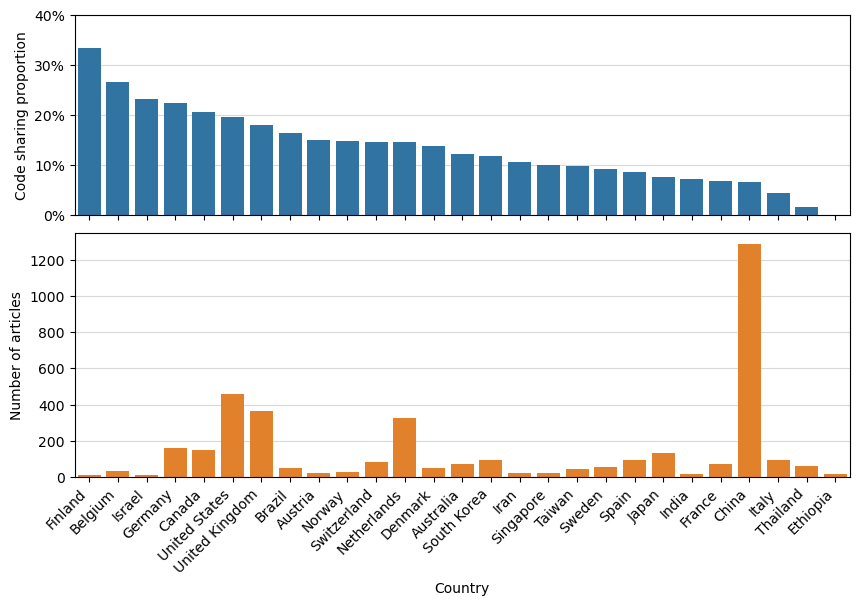

In [15]:
# ----------------------------
# Choose country column
# ----------------------------
country_col = (
    "country_first_author_institution_normalized"
    if "country_first_author_institution_normalized" in df_inscope.columns
    else "country_first_author_institution"
)

# ----------------------------
# Filter to countries with > 10 papers
# ----------------------------
country_counts = df_inscope[country_col].dropna().value_counts()
valid_countries = country_counts[country_counts > 10].index
dfc = df_inscope[df_inscope[country_col].isin(valid_countries)].copy()

# ----------------------------
# Reported code mask
# ----------------------------
reported_mask = (
    dfc["repo_status"].isin([RepoStatus.OK.value, RepoStatus.NOT_SUPPORTED.value])
    | (dfc["repo_url"] == "Appendix")
)

# ----------------------------
# Aggregate support + ratio
# ----------------------------
summary = (
    dfc.assign(is_reported=reported_mask)
    .groupby(country_col, dropna=False)
    .agg(
        support=("is_reported", "size"),
        reported_ratio=("is_reported", "mean"),
    )
    .reset_index()
)

# Sort by code sharing ratio DESC, then support DESC
summary = summary.sort_values(
    ["reported_ratio", "support"], ascending=[False, False]
).reset_index(drop=True)

countries = summary[country_col].tolist()

# ----------------------------
# Colors: same Seaborn deep palette as other figure
# ----------------------------
deep = sns.color_palette()
color_ratio = deep[0]
color_support = deep[1]

# ----------------------------
# Two-panel figure
# ----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [0.45, 0.55], "hspace": 0.08}
)

ax1, ax2 = axes

# Top panel: reported ratio
sns.barplot(
    data=summary,
    x=country_col,
    y="reported_ratio",
    order=countries,
    color=color_ratio,
    ax=ax1,
)

# Bottom panel: support
sns.barplot(
    data=summary,
    x=country_col,
    y="support",
    order=countries,
    color=color_support,
    ax=ax2,
)

# ----------------------------
# Formatting
# ----------------------------
ax1.set_ylabel("Code sharing proportion")
ax2.set_ylabel("Number of articles")
ax2.set_xlabel("Country")

ax1.set_ylim(0, 0.4)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Rotate x tick labels only on bottom panel
ax2.tick_params(axis="x", rotation=45)
for label in ax2.get_xticklabels():
    label.set_horizontalalignment("right")

# Clean white background + horizontal gridlines
for ax in axes:
    # ax.set_facecolor("white")
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, which="major", color="0.85", linestyle="-", linewidth=0.8)
    ax.xaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)

# Remove duplicate x label clutter on top panel
ax1.set_xlabel("")
ax1.tick_params(axis="x", labelbottom=False)

plt.tight_layout()
plt.savefig("../figures/figure4_code_sharing_countries.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
summary.round(3)

,country_first_author_institution_normalized,support,reported_ratio
0,Finland,12,0.333
1,Belgium,30,0.267
2,Israel,13,0.231
3,Germany,157,0.223
4,Canada,151,0.205
5,United States,460,0.196
6,United Kingdom,362,0.180
7,Brazil,49,0.163
8,Austria,20,0.150
9,Norway,27,0.148


## Aggregate per journal

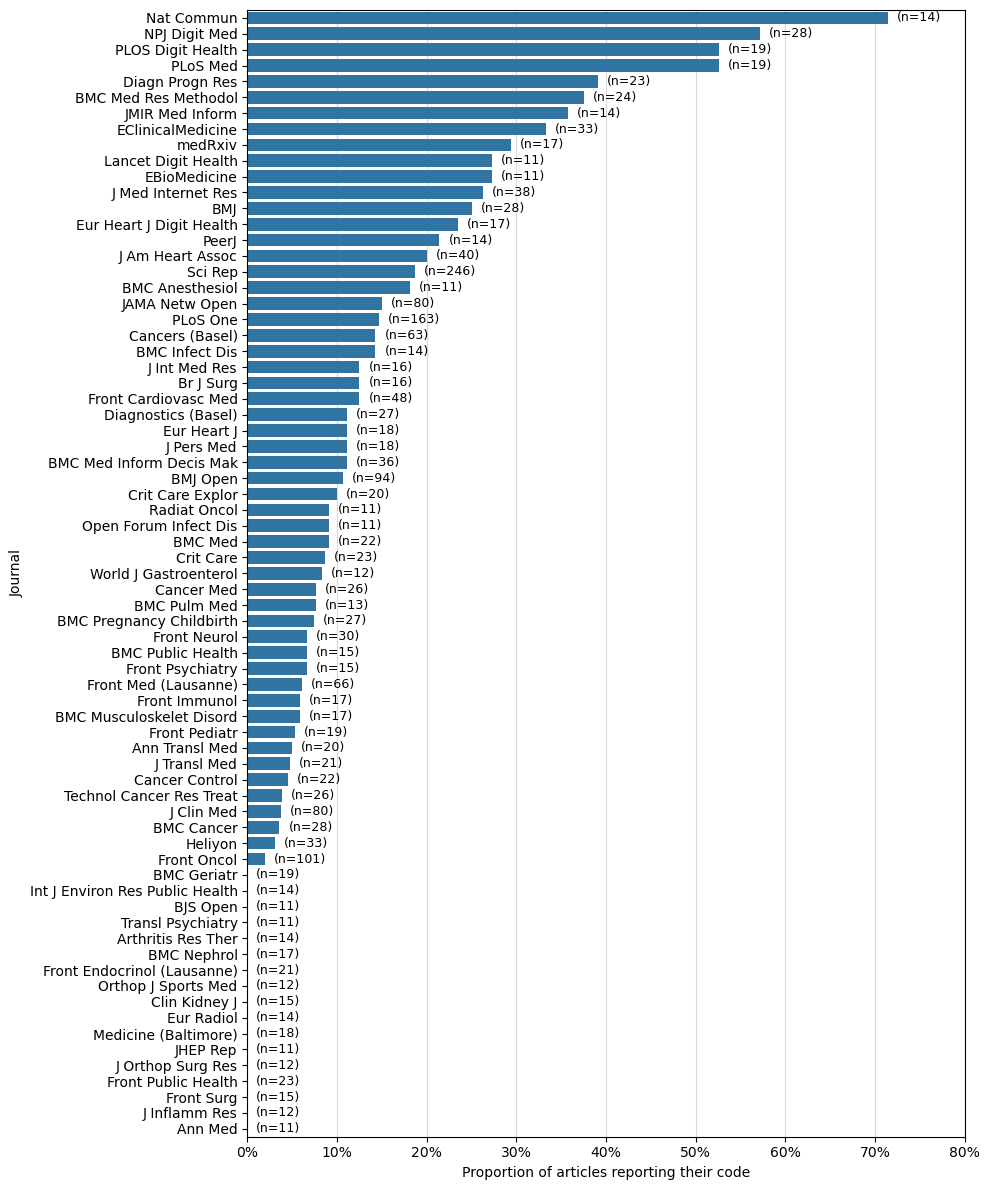

In [17]:
# Compute ratio of non-empty repo_url per Journal/Book
counts = df_inscope["Journal/Book"].value_counts()
valid_journals = counts[counts > 10].index

reported_mask = (
    df_inscope["repo_status"].isin(
        [RepoStatus.OK.value, RepoStatus.NOT_SUPPORTED.value]
    )
    | (df_inscope["repo_url"] == "Appendix")
)

ratio_df = (
    df_inscope[df_inscope["Journal/Book"].isin(valid_journals)]
    .assign(is_reported=reported_mask)
    .groupby("Journal/Book", dropna=False)["is_reported"]
    .mean()  # proportion reporting
    .reset_index(name="reported_ratio")
)

support_df = (
    df_inscope[df_inscope["Journal/Book"].isin(valid_journals)]
    .groupby("Journal/Book")
    .size()
    .reset_index(name="support")
)

# Sort ascending (increasing order of proportion reporting)
ratio_df = ratio_df.sort_values("reported_ratio", ascending=False)
ratio_df = ratio_df.merge(support_df, on="Journal/Book", how="left")

# Plot
plt.figure(figsize=(10, 12))
sns.barplot(
    data=ratio_df,
    x="reported_ratio",
    y="Journal/Book",
    # palette="viridis"
)
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))

ax.set_axisbelow(True)
ax.xaxis.grid(True, which="major", color="0.85", linestyle="-", linewidth=0.8)
ax.yaxis.grid(False)

for i, row in ratio_df.iterrows():
    ax.text(
        row["reported_ratio"] + 0.01,  # slightly to the right of the bar
        i,
        f"(n={row['support']})",
        va="center",
        fontsize=9,
        color="black"
    )
plt.xlabel("Proportion of articles reporting their code")
plt.ylabel("Journal")
# plt.title("Proportion of papers reporting their code by Journal (for journals with >20 papers)")
plt.xlim(0, 0.8)
plt.tight_layout()
plt.savefig("../figures/figure3_code_sharing_journals.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Count journals with reported_ratio of 0
num_zero_ratio = (ratio_df["reported_ratio"] == 0).sum()
print(f"Number of journals with code sharing ratio of 0: {num_zero_ratio} out of {len(ratio_df)}")

Number of journals with code sharing ratio of 0: 17 out of 71


In [36]:
ratio_df.round(3)

,Journal/Book,reported_ratio,support
0,Nat Commun,0.714,14
1,NPJ Digit Med,0.571,28
2,PLOS Digit Health,0.526,19
3,PLoS Med,0.526,19
4,Diagn Progn Res,0.391,23
...,...,...,...
66,J Orthop Surg Res,0.000,12
67,Front Public Health,0.000,23
68,Front Surg,0.000,15
69,J Inflamm Res,0.000,12


In [18]:
df_tripod = pd.read_csv("../data/00_references/TRIPOD/TRIPOD_combined_references.csv")
df_tripod_ai = pd.read_csv("../data/00_references/TRIPOD_AI/TRIPOD_AI_combined_references.csv")

In [19]:
# Define the reporting condition
is_reported = (
    df_inscope["repo_status"].isin(
        [RepoStatus.OK.value, RepoStatus.NOT_SUPPORTED.value]
    )
    | (df_inscope["repo_url"] == "Appendix")
)

df_inscope_with_flag = df_inscope.copy()
df_inscope_with_flag["is_reported"] = is_reported

# Create flags for TRIPOD membership
df_inscope_with_flag["in_tripod"] = df_inscope_with_flag["PMID"].isin(df_tripod["PMID"])
df_inscope_with_flag["in_tripod_ai"] = df_inscope_with_flag["PMID"].isin(df_tripod_ai["PMID"])

# Categorize each paper
def categorize_paper(row):
    in_t = row["in_tripod"]
    in_ai = row["in_tripod_ai"]
    
    if in_t and in_ai:
        return "Both TRIPOD and TRIPOD-AI"
    elif in_t:
        return "TRIPOD only"
    elif in_ai:
        return "TRIPOD-AI only"
    else:
        return "Neither"

df_inscope_with_flag["category"] = df_inscope_with_flag.apply(categorize_paper, axis=1)

# Add year column
df_inscope_with_flag["Create Date"] = pd.to_datetime(
    df_inscope_with_flag["Create Date"], format="%Y/%m/%d", errors="coerce"
)
df_inscope_with_flag["year"] = df_inscope_with_flag["Create Date"].dt.year

# Calculate ratios for each category and year
results = []
for year in sorted(df_inscope_with_flag["year"].dropna().unique()):
    for category in ["TRIPOD only", "TRIPOD-AI only", "Both TRIPOD and TRIPOD-AI"]:
        subset = df_inscope_with_flag[
            (df_inscope_with_flag["year"] == year) 
            & (df_inscope_with_flag["category"] == category)
        ]
        if len(subset) > 0:
            n_reported = subset["is_reported"].sum()
            n_total = len(subset)
            ratio = n_reported / n_total
            results.append({
                "Year": int(year),
                "Category": category,
                "Reported": int(n_reported),
                "Total": int(n_total),
                "Ratio": f"{ratio:.1%}"
            })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 Year                  Category  Reported  Total Ratio
 2015               TRIPOD only         1     16  6.2%
 2016               TRIPOD only         2     44  4.5%
 2017               TRIPOD only         5     84  6.0%
 2018               TRIPOD only        10    115  8.7%
 2019               TRIPOD only        19    166 11.4%
 2020               TRIPOD only        35    316 11.1%
 2021               TRIPOD only        47    539  8.7%
 2022               TRIPOD only        71    699 10.2%
 2023               TRIPOD only        99    700 14.1%
 2024               TRIPOD only       103    761 13.5%
 2024            TRIPOD-AI only        15     53 28.3%
 2024 Both TRIPOD and TRIPOD-AI         1      6 16.7%
 2025               TRIPOD only        42    356 11.8%
 2025            TRIPOD-AI only        30    101 29.7%
 2025 Both TRIPOD and TRIPOD-AI         2     11 18.2%


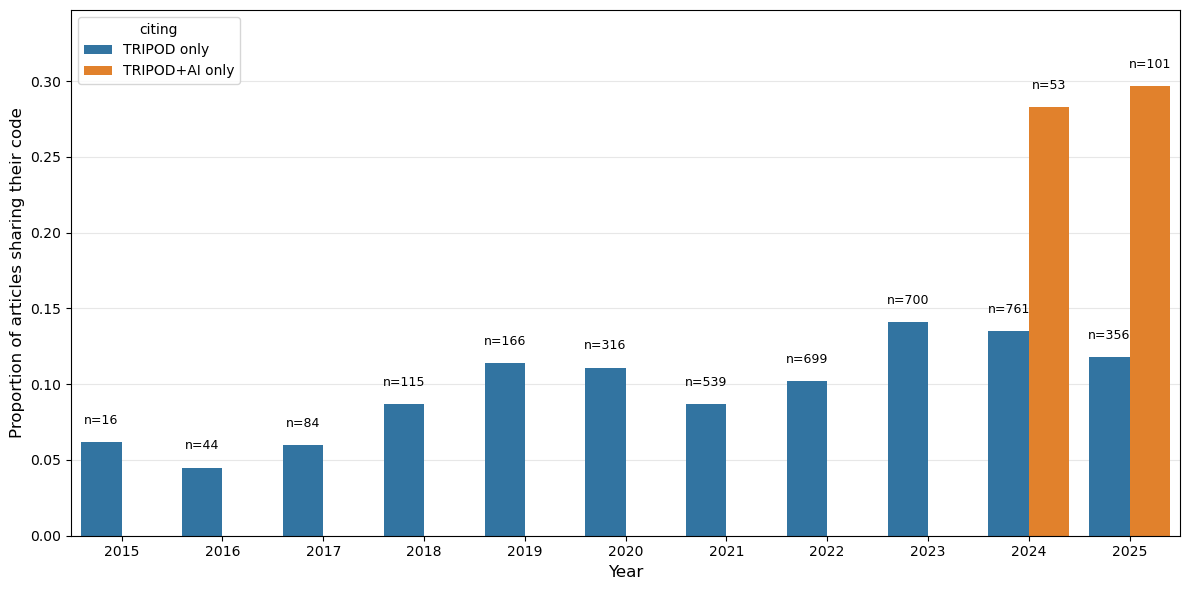

In [20]:
# ------------------------------------------------------------------
# Copy + year
# ------------------------------------------------------------------
df_plot = df_inscope.copy()

df_plot["Create Date"] = pd.to_datetime(
    df_plot["Create Date"], format="%Y/%m/%d", errors="coerce"
)
df_plot["year"] = df_plot["Create Date"].dt.year
df_plot = df_plot[df_plot["year"].notna()]

# ------------------------------------------------------------------
# Reporting flag (code sharing)
# ------------------------------------------------------------------
df_plot["is_reported"] = (
    df_plot["repo_status"].isin([RepoStatus.OK.value, RepoStatus.NOT_SUPPORTED.value])
    | (df_plot["repo_url"] == "Appendix")
)

# ------------------------------------------------------------------
# TRIPOD membership flags
# ------------------------------------------------------------------
df_plot["in_tripod"] = df_plot["PMID"].isin(df_tripod["PMID"])
df_plot["in_tripod_ai"] = df_plot["PMID"].isin(df_tripod_ai["PMID"])

# Keep ONLY exclusive papers
df_plot = df_plot[(df_plot["in_tripod"] ^ df_plot["in_tripod_ai"])].copy()

df_plot["citing"] = df_plot.apply(
    lambda r: "TRIPOD only" if r["in_tripod"] else "TRIPOD+AI only",
    axis=1
)

# ------------------------------------------------------------------
# Aggregate by year + citing
# ------------------------------------------------------------------
year_cat_df = (
    df_plot
    .groupby(["year", "citing"], dropna=False)
    .agg(
        reported_ratio=("is_reported", "mean"),
        support=("is_reported", "size"),
        n_reported=("is_reported", "sum"),
    )
    .reset_index()
)

year_cat_df["reported_ratio"] = year_cat_df["reported_ratio"].round(3)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
hue_order = ["TRIPOD only", "TRIPOD+AI only"]
years = sorted(year_cat_df["year"].unique())

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=year_cat_df,
    x="year",
    y="reported_ratio",
    hue="citing",
    order=years,
    hue_order=hue_order,
    dodge=True,
)

ax.set_axisbelow(True)
ax.yaxis.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.3)
ax.xaxis.grid(False)

# ------------------------------------------------------------------
# Exact lookup table
# ------------------------------------------------------------------
plot_lookup = {
    (int(row.year), row.citing): {
        "reported_ratio": float(row.reported_ratio),
        "support": int(row.support),
    }
    for row in year_cat_df.itertuples(index=False)
}

# ------------------------------------------------------------------
# Manual labels from real drawn bars only
# ------------------------------------------------------------------
for container, hue_name in zip(ax.containers, hue_order):
    patches = [p for p in container.patches if p is not None]

    for patch in patches:
        height = patch.get_height()
        if pd.isna(height) or height <= 0:
            continue

        x_center = patch.get_x() + patch.get_width() / 2

        # recover the year from the nearest x tick
        year_idx = min(range(len(years)), key=lambda i: abs(ax.get_xticks()[i] - x_center))
        year = years[year_idx]

        info = plot_lookup.get((year, hue_name))
        if info is None:
            continue

        ax.text(
            x_center,
            height + 0.01,
            f"n={info['support']}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Proportion of articles sharing their code", fontsize=12)
ax.set_ylim(0, min(1.0, year_cat_df["reported_ratio"].max() + 0.05))

plt.tight_layout()
plt.savefig("../figures/figure2_code_sharing_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
year_cat_df

,year,citing,reported_ratio,support,n_reported
0,2015,TRIPOD only,0.062,16,1
1,2016,TRIPOD only,0.045,44,2
2,2017,TRIPOD only,0.060,84,5
3,2018,TRIPOD only,0.087,115,10
4,2019,TRIPOD only,0.114,166,19
5,2020,TRIPOD only,0.111,316,35
6,2021,TRIPOD only,0.087,539,47
7,2022,TRIPOD only,0.102,699,71
8,2023,TRIPOD only,0.141,700,99
9,2024,TRIPOD only,0.135,761,103


## Repository Assessment

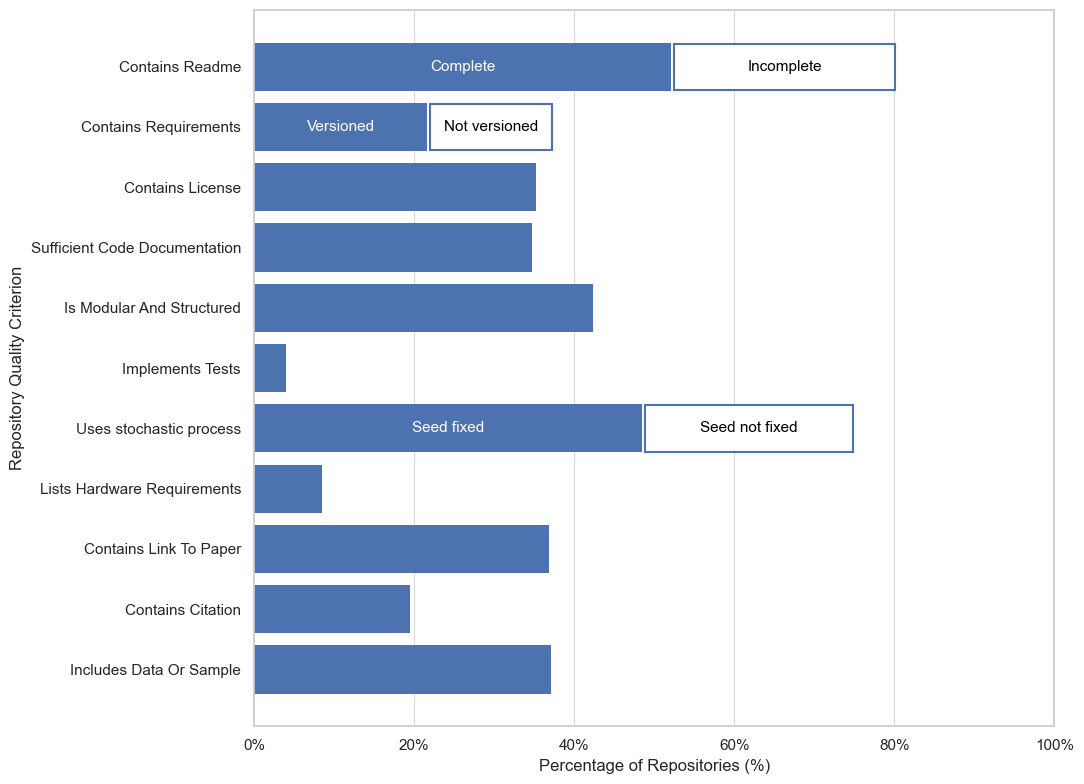

In [22]:
# --------------------------------------------
# Filter to evaluated repos
# --------------------------------------------
df = df_repo_assessment[df_repo_assessment["repo_status"] == RepoStatus.OK].copy()

# ------------------------------------------------------------
# 1. Define repo-quality boolean columns
# ------------------------------------------------------------
base_cols = [
    "contains_license",
    "sufficient_code_documentation",
    "is_modular_and_structured",
    "implements_tests",
    "fixes_seed_if_stochastic",
    "lists_hardware_requirements",
    "contains_link_to_paper",
    "contains_citation",
    "includes_data_or_sample",
]

base_cols = [c for c in base_cols if c in df.columns]

N = len(df)
if N == 0:
    raise ValueError("No repositories after filtering to RepoStatus.OK")

# ------------------------------------------------------------
# 2. Build plotting rows
# ------------------------------------------------------------
plot_rows = []

# README conditional bar
if "contains_readme" in df.columns and "readme_purpose_and_outputs" in df.columns:
    readme_present = df["contains_readme"] == True

    readme_complete = readme_present & (df["readme_purpose_and_outputs"] == True)
    readme_incomplete = readme_present & (df["readme_purpose_and_outputs"] == False)

    plot_rows.extend([
        {
            "criterion": "contains_readme",
            "value": 100 * readme_complete.sum() / N,
            "segment": "Complete README",
            "text": "Complete",
        },
        {
            "criterion": "contains_readme",
            "value": 100 * readme_incomplete.sum() / N,
            "segment": "Incomplete README",
            "text": "Incomplete",
        },
    ])

# Requirements conditional bar
if "contains_requirements" in df.columns and "requirements_dependency_versions" in df.columns:
    req_present = df["contains_requirements"] == True

    req_complete = req_present & (df["requirements_dependency_versions"] == True)
    req_incomplete = req_present & (df["requirements_dependency_versions"] == False)

    plot_rows.extend([
        {
            "criterion": "contains_requirements",
            "value": 100 * req_complete.sum() / N,
            "segment": "Versioned dependencies",
            "text": "Versioned",
        },
        {
            "criterion": "contains_requirements",
            "value": 100 * req_incomplete.sum() / N,
            "segment": "Incomplete dependencies",
            "text": "Not versioned",
        },
    ])

# Regular criteria
for col in base_cols:
    if col == "fixes_seed_if_stochastic":
        fixes_seed = df["fixes_seed_if_stochastic"] == True
        not_fix_seed = df["fixes_seed_if_stochastic"] == False

        plot_rows.extend([
            {
                "criterion": "Uses stochastic process",
                "value": 100 * fixes_seed.sum() / N,
                "segment": "Seed fixed",
                "text": "Seed fixed",
            },
            {
                "criterion": "Uses stochastic process",
                "value": 100 * not_fix_seed.sum() / N,
                "segment": "Seed not fixed",
                "text": "Seed not fixed",
            },
        ])
        continue

    evaluated = df[col].notna().sum()
    if evaluated == 0:
        continue

    pct_true = 100 * df.loc[df[col].notna(), col].astype(bool).sum() / N

    plot_rows.append({
        "criterion": col,
        "value": pct_true,
        "segment": "True",
        "text": "",
    })

plot_df = pd.DataFrame(plot_rows)

# ------------------------------------------------------------
# 2b. Explicit criterion order
# ------------------------------------------------------------
criterion_order = []

if (plot_df["criterion"] == "contains_readme").any():
    criterion_order.append("contains_readme")
if (plot_df["criterion"] == "contains_requirements").any():
    criterion_order.append("contains_requirements")

for c in base_cols:
    label = "Uses stochastic process" if c == "fixes_seed_if_stochastic" else c
    if (plot_df["criterion"] == label).any() and label not in criterion_order:
        criterion_order.append(label)

# ------------------------------------------------------------
# 2c. Pivot for stacked horizontal bars
# ------------------------------------------------------------
segment_order = [
    "Complete README",
    "Incomplete README",
    "Versioned dependencies",
    "Incomplete dependencies",
    "Seed fixed",
    "Seed not fixed",
    "True",
]

plot_wide = (
    plot_df.pivot_table(
        index="criterion",
        columns="segment",
        values="value",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(index=criterion_order)
)

segment_order_present = [s for s in segment_order if s in plot_wide.columns]
plot_wide = plot_wide[segment_order_present]

# ------------------------------------------------------------
# Pretty labels
# ------------------------------------------------------------
def pretty_label(s):
    if s == "Uses stochastic process":
        return s
    return s.replace("_", " ").title()

pretty_labels = [pretty_label(c) for c in plot_wide.index]

# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
sns.set_theme(style="whitegrid")

palette = sns.color_palette()
blue = palette[0]

fig, ax = plt.subplots(figsize=(11, 8))

left = pd.Series(0, index=plot_wide.index, dtype=float)

filled_segments = {"Complete README", "Versioned dependencies", "Seed fixed", "True"}
outlined_segments = {"Incomplete README", "Incomplete dependencies", "Seed not fixed"}

for segment in segment_order_present:
    values = plot_wide[segment]

    is_filled = segment in filled_segments

    bars = ax.barh(
        y=plot_wide.index,
        width=values,
        left=left,
        color=blue if is_filled else "white",
        linewidth=0,
        label=segment,
    )

    if segment in outlined_segments:
        for i, (bar, val) in enumerate(zip(bars, values)):
            if val <= 0:
                continue

            x0 = left.iloc[i]
            y0 = bar.get_y()
            h = bar.get_height()

            inner_pad_x = min(0.4, val * 0.04)
            inner_pad_y = h * 0.02

            inner_width = max(val - 2 * inner_pad_x, 0)
            inner_height = max(h - 2 * inner_pad_y, 0)

            if inner_width > 0 and inner_height > 0:
                inner_rect = plt.Rectangle(
                    (x0 + inner_pad_x, y0 + inner_pad_y),
                    inner_width,
                    inner_height,
                    fill=False,
                    edgecolor=blue,
                    linewidth=1.5,
                )
                ax.add_patch(inner_rect)

    # Add inside labels for multi-part bars only
    for i, (bar, val) in enumerate(zip(bars, values)):
        if val <= 0:
            continue

        criterion = plot_wide.index[i]
        text = plot_df.loc[
            (plot_df["criterion"] == criterion) & (plot_df["segment"] == segment),
            "text",
        ]

        label = text.iloc[0] if len(text) else ""
        if label and val >= 8:
            text_color = "white" if segment in {"Complete README", "Versioned dependencies", "Seed fixed"} else "black"

            ax.text(
                left.iloc[i] + val / 2,
                bar.get_y() + bar.get_height() / 2,
                label,
                ha="center",
                va="center",
                fontsize=11,
                color=text_color,
            )

    left = left + values

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_yticks(range(len(plot_wide.index)))
ax.set_yticklabels(pretty_labels)

ax.set_xlabel("Percentage of Repositories (%)")
ax.set_ylabel("Repository Quality Criterion")
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))

ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.xaxis.grid(True, which="major", color="0.85", linestyle="-", linewidth=0.8)
ax.yaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(True)

ax.invert_yaxis()
ax.legend().remove()

plt.tight_layout()
plt.savefig("../figures/figure5_repo_practices.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
plot_rows

[{'criterion': 'contains_readme',
  'value': np.float64(52.10526315789474),
  'segment': 'Complete README',
  'text': 'Complete'},
 {'criterion': 'contains_readme',
  'value': np.float64(28.42105263157895),
  'segment': 'Incomplete README',
  'text': 'Incomplete'},
 {'criterion': 'contains_requirements',
  'value': np.float64(21.57894736842105),
  'segment': 'Versioned dependencies',
  'text': 'Versioned'},
 {'criterion': 'contains_requirements',
  'value': np.float64(16.05263157894737),
  'segment': 'Incomplete dependencies',
  'text': 'Not versioned'},
 {'criterion': 'contains_license',
  'value': np.float64(35.26315789473684),
  'segment': 'True',
  'text': ''},
 {'criterion': 'sufficient_code_documentation',
  'value': np.float64(34.73684210526316),
  'segment': 'True',
  'text': ''},
 {'criterion': 'is_modular_and_structured',
  'value': np.float64(42.36842105263158),
  'segment': 'True',
  'text': ''},
 {'criterion': 'implements_tests',
  'value': np.float64(3.9473684210526314),


## Comparing Journals' code sharing practices

In [16]:
# ------------------------------------------------------------
# 1) Filter to OK repositories
# ------------------------------------------------------------
df = df_repo_assessment[df_repo_assessment["repo_status"] == RepoStatus.OK].copy()

journal_col = "Journal/Book"

criteria = [
    "contains_readme",
    "contains_requirements",
    "contains_license",
    "sufficient_code_documentation",
    "is_modular_and_structured",
    "implements_tests",
    "fixes_seed_if_stochastic",
    "lists_hardware_requirements",
    "contains_link_to_paper",
    "contains_citation",
    "includes_data_or_sample",
]
criteria = [c for c in criteria if c in df.columns]

# Clean journals
df[journal_col] = df[journal_col].astype("string").str.strip()
df = df.dropna(subset=[journal_col])

# Coerce criteria to numeric 0/1
for c in criteria:
    df[c] = df[c].replace({True: 1, False: 0, "True": 1, "False": 0})
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ------------------------------------------------------------
# 2) Add per-repo average across criteria
# ------------------------------------------------------------
AVG_COL = "__avg_across_criteria__"
df[AVG_COL] = df[criteria].mean(axis=1, skipna=True)

# Global means
global_mean = df[criteria].mean()
global_mean_avg = float(df[AVG_COL].mean())

# ------------------------------------------------------------
# 3) Journals with >5 OK repos + journal means
# ------------------------------------------------------------
journal_n = df[journal_col].value_counts()
valid_journals = journal_n[journal_n > 5].index.astype(str)

df_j = df[df[journal_col].astype(str).isin(valid_journals)].copy()
df_j[journal_col] = df_j[journal_col].astype(str)

journal_mean_long = (
    df_j.groupby(journal_col)[criteria]
      .mean()
      .stack()
      .rename("mean")
      .reset_index()
      .rename(columns={"level_1": "criterion"})
)
journal_mean_long[journal_col] = journal_mean_long[journal_col].astype(str)
journal_mean_long["n_in_journal"] = journal_mean_long[journal_col].map(journal_n).astype(int)
journal_mean_long = journal_mean_long.dropna(subset=["mean"])

# Journal "average across criteria"
journal_avg = (
    df_j.groupby(journal_col)[AVG_COL]
      .mean()
      .rename("mean")
      .reset_index()
)
journal_avg["criterion"] = AVG_COL
journal_avg[journal_col] = journal_avg[journal_col].astype(str)
journal_avg["n_in_journal"] = journal_avg[journal_col].map(journal_n).astype(int)

journal_mean_long = pd.concat(
    [journal_mean_long, journal_avg[[journal_col, "criterion", "mean", "n_in_journal"]]],
    ignore_index=True
)

pretty = lambda s: s.replace("_", " ").title()
def pretty_criterion(c):
    return "Average Across Criteria" if c == AVG_COL else pretty(c)

# ------------------------------------------------------------
# 4) Sort journals by decreasing "average across criteria"
#    and compute where Global mean should be inserted in the legend
# ------------------------------------------------------------
avg_by_journal = (
    journal_avg.set_index(journal_col)["mean"]
    .reindex(valid_journals.astype(str))
    .dropna()
)

journals_sorted = avg_by_journal.sort_values(ascending=False).index.tolist()
journal_label = {j: f"{j} (n={int(journal_n[j])})" for j in journals_sorted}

# Insertion index for global mean in descending order
global_insert_idx = int((avg_by_journal.loc[journals_sorted] >= global_mean_avg).sum())

# Styles
symbols = [
    "square", "diamond", "cross", "x",
    "triangle-up", "triangle-down", "triangle-left", "triangle-right",
    "star", "hexagon", "pentagon", "hourglass", "bowtie"
]
palette = qualitative.Pastel + qualitative.Safe

journal_style = {
    j: dict(
        color=palette[i % len(palette)],
        symbol=symbols[i % len(symbols)],
    )
    for i, j in enumerate(journals_sorted)
}

# ------------------------------------------------------------
# 5) Plot
# ------------------------------------------------------------
criteria_plot = criteria + [AVG_COL]
nrows = len(criteria_plot)

fig = make_subplots(
    rows=nrows,
    cols=2,
    column_widths=[0.11, 0.30],
    horizontal_spacing=0,
    vertical_spacing=0.03,
    specs=[[{"type": "xy"}, {"type": "xy"}] for _ in range(nrows)],
)

# We'll draw panel backgrounds ourselves, so keep plot bg transparent
fig.update_layout(
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="white",
)

# Panel styling
PLOT_PANEL_BG = "#F5F5F5"
PLOT_PANEL_BG_LAST = "#ECECEC"
PLOT_PANEL_BORDER = "#D9D9D9"
PLOT_PANEL_BORDER_LAST = "#BDBDBD"
X_GRID_COLOR = "#E0E0E0"
RADIUS = 0.008

# Marker styling (your request)
MARKER_SIZE = 12
GLOBAL_LINE_WIDTH = 2
GLOBAL_CIRCLE_LINE_WIDTH = 2  # "width of 2" for the open circle outline

def rounded_rect_path(x0, x1, y0, y1, r):
    r = min(r, (x1 - x0) / 2, (y1 - y0) / 2)
    return (
        f"M {x0+r},{y0} "
        f"L {x1-r},{y0} Q {x1},{y0} {x1},{y0+r} "
        f"L {x1},{y1-r} Q {x1},{y1} {x1-r},{y1} "
        f"L {x0+r},{y1} Q {x0},{y1} {x0},{y1-r} "
        f"L {x0},{y0+r} Q {x0},{y0} {x0+r},{y0} Z"
    )

for i, c in enumerate(criteria_plot, start=1):
    is_avg_row = (c == AVG_COL)
    label = pretty_criterion(c)

    # Left label cell background
    fig.add_shape(
        type="rect",
        x0=0, x1=1, y0=0, y1=1,
        xref="x domain", yref="y domain",
        fillcolor="white",
        line=dict(width=0),
        layer="below",
        row=i, col=1,
    )

    # Left column label
    fig.add_trace(
        go.Scatter(
            x=[0.02], y=[0],
            mode="text",
            text=[label],
            textposition="middle right",
            textfont=dict(size=15 if is_avg_row else 13, family="Arial Black" if is_avg_row else None),
            showlegend=False,
            hoverinfo="skip",
        ),
        row=i, col=1,
    )
    fig.update_xaxes(row=i, col=1, visible=False, showgrid=False, zeroline=False, range=[0, 1])
    fig.update_yaxes(row=i, col=1, visible=False, showgrid=False, zeroline=False, range=[-1, 1])

    # Global mean for this row
    gm = global_mean_avg if is_avg_row else float(global_mean[c])

    # Global mean vertical line (no legend)
    fig.add_shape(
        type="line",
        x0=gm, x1=gm,
        y0=-0.22, y1=0.22,
        line=dict(color="red", width=GLOBAL_LINE_WIDTH),
        row=i, col=2,
    )

    # Right column: journals + global mean marker inserted in legend order (row 1)
    d = journal_mean_long[journal_mean_long["criterion"] == c].copy()
    legend_on = (i == 1)

    inserted = False
    for k, j in enumerate(journals_sorted):
        # Insert "Global mean" legend entry at correct rank (row 1 only)
        if legend_on and (not inserted) and (k == global_insert_idx):
            fig.add_trace(
                go.Scatter(
                    x=[gm], y=[0.0],
                    mode="markers",
                    marker=dict(
                        color="red",
                        size=MARKER_SIZE,
                        symbol="circle-open",
                        line=dict(width=GLOBAL_CIRCLE_LINE_WIDTH),
                    ),
                    name="Global mean",
                    showlegend=True,
                    legendgroup="__global__",
                    hovertemplate=f"Criterion: {label}<br>Global mean: {gm:.3f}<extra></extra>",
                ),
                row=i, col=2,
            )
            inserted = True

        dj = d[d[journal_col] == j]
        if dj.empty:
            continue

        st = journal_style[j]
        xval = float(dj["mean"].iloc[0])
        nval = int(dj["n_in_journal"].iloc[0])

        fig.add_trace(
            go.Scatter(
                x=[xval], y=[0.0],
                mode="markers",
                marker=dict(
                    color=st["color"],
                    symbol=st["symbol"],
                    size=MARKER_SIZE,
                    line=dict(width=0),
                ),
                name=journal_label[j],
                showlegend=legend_on,
                legendgroup=j,
                hovertemplate=(
                    f"Journal: {j}<br>"
                    f"n: {nval}<br>"
                    f"Criterion: {label}<br>"
                    "Mean: %{x:.3f}<extra></extra>"
                ),
            ),
            row=i, col=2,
        )

    # If global mean belongs at the end (row 1 only)
    if legend_on and (not inserted):
        fig.add_trace(
            go.Scatter(
                x=[gm], y=[0.0],
                mode="markers",
                marker=dict(
                    color="red",
                    size=MARKER_SIZE,
                    symbol="circle-open",
                    line=dict(width=GLOBAL_CIRCLE_LINE_WIDTH),
                ),
                name="Global mean",
                showlegend=True,
                legendgroup="__global__",
                hovertemplate=f"Criterion: {label}<br>Global mean: {gm:.3f}<extra></extra>",
            ),
            row=i, col=2,
        )
    elif not legend_on:
        # Still plot the global mean marker on every row (no legend)
        fig.add_trace(
            go.Scatter(
                x=[gm], y=[0.0],
                mode="markers",
                marker=dict(
                    color="red",
                    size=MARKER_SIZE,
                    symbol="circle-open",
                    line=dict(width=GLOBAL_CIRCLE_LINE_WIDTH),
                ),
                name="Global mean",
                showlegend=False,
                legendgroup="__global__",
                hovertemplate=f"Criterion: {label}<br>Global mean: {gm:.3f}<extra></extra>",
            ),
            row=i, col=2,
        )

    # Axes (x-axis only on last row; vertical gridlines only)
    fig.update_xaxes(
        range=[-0.02, 1.02],
        showgrid=True,
        gridcolor=X_GRID_COLOR,
        zeroline=False,
        title_text="Proportion of articles, aggregated by journal" if i == nrows else "",
        showticklabels=(i == nrows),
        ticks="outside" if i == nrows else "",
        row=i, col=2,
    )
    fig.update_yaxes(
        range=[-0.3, 0.3],
        showticklabels=False,
        ticks="",
        zeroline=False,
        showgrid=False,
        row=i, col=2,
    )

# Rounded plot panels for right column
for i in range(1, nrows + 1):
    ax_id = 2 * i  # right subplot axes index
    xa = fig.layout[f"xaxis{ax_id}"]
    ya = fig.layout[f"yaxis{ax_id}"]

    x0, x1 = xa.domain
    y0, y1 = ya.domain

    is_last = (i == nrows)

    fig.add_shape(
        type="path",
        path=rounded_rect_path(x0, x1, y0, y1, RADIUS),
        xref="paper",
        yref="paper",
        fillcolor=PLOT_PANEL_BG_LAST if is_last else PLOT_PANEL_BG,
        line=dict(
            color=PLOT_PANEL_BORDER_LAST if is_last else PLOT_PANEL_BORDER,
            width=2 if is_last else 1
        ),
        layer="below",
    )

fig.update_layout(
    width=1200,
    height=max(450, 70 * nrows),
    margin=dict(l=20, r=20, t=20, b=40),
    legend=dict(
        title="Journals (sorted by avg across criteria)",
        x=1.02, y=1.0,
        xanchor="left", yanchor="top",
        itemsizing="constant",
        tracegroupgap=2,
    ),
)

fig.show()
fig.write_image("../figures/figure6_repo_practices_by_journal.png", scale=3)  # scale controls sharpness

/var/folders/h6/z36012w55gz3qplddg4wtlf80000gn/T/ipykernel_23048/73591161.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c] = df[c].replace({True: 1, False: 0, "True": 1, "False": 0})


In [27]:
avg_by_journal.sort_values(ascending=False).round(3)

Journal/Book
PLOS Digit Health       0.477
Diagn Progn Res         0.468
JAMA Netw Open          0.434
BMC Med Res Methodol    0.406
BMJ Open                0.387
PLoS Med                0.370
Sci Rep                 0.356
NPJ Digit Med           0.347
PLoS One                0.336
EClinicalMedicine       0.289
Cancers (Basel)         0.268
J Med Internet Res      0.210
J Am Heart Assoc        0.161
Name: mean, dtype: float64

In [28]:
avg_by_journal.sort_values(ascending=False).iloc[0] - global_mean_avg

np.float64(0.11913875598086127)

## Programming Languages

In [24]:
df_inscope["coding_languages"].value_counts()

coding_languages
[r]                                                    123
[python]                                                98
[matlab]                                                 2
[stata]                                                  2
[r, markdown]                                            1
                                                      ... 
[r, html]                                                1
[r, python]                                              1
[r, sas, python, shell]                                  1
[python, shell, dockerfile, yaml, jupyter notebook]      1
[json]                                                   1
Name: count, Length: 134, dtype: int64

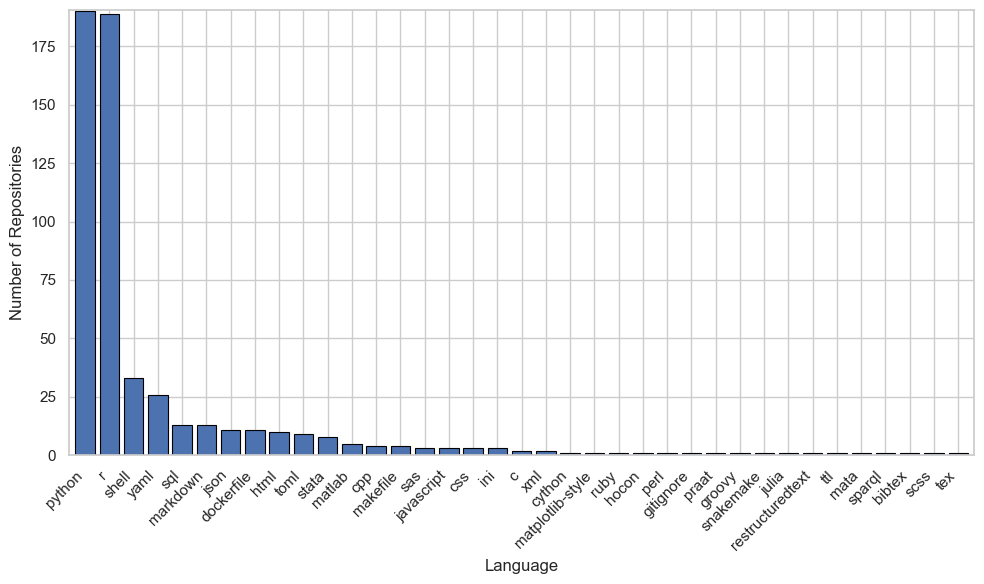

In [30]:
# 1) Canonicalize duplicate namings (no clustering)
CANONICAL = {
    # shell variants
    "bash": "shell",
    "sh": "shell",
    "shell or bash": "shell",

    # c/c++ variants
    "c++": "cpp",
    "c/c++ headers": "cpp",

    # minor variants
    "r markdown": "rmarkdown",
    "rmd": "rmarkdown",

    # notebook naming variants (if they appear)
    "jupyter": "jupyter notebook",
    "jupyter-notebook": "jupyter notebook",
    "ipynb": "jupyter notebook",

    # docker variants
    "docker": "dockerfile",
}
NOTEBOOKS = {
    "jupyter notebook",
    "rmarkdown",
    "quarto",
}

def normalize_lang(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return None
    s = str(x).strip().lower()
    if s == "":
        return None

    s = CANONICAL.get(s, s)          # unify synonyms

    # excluding notebooks
    if s in NOTEBOOKS:
        return None
    
    return s

langs = (
    df_repo_assessment["coding_languages"]
    .dropna()
    .explode()
    .map(normalize_lang)
    .dropna()
)

lang_counts = langs.value_counts()

fig, ax = plt.subplots(figsize=(10, 6))

lang_counts.plot(
    kind="bar",
    ax=ax,
    width=0.8,
    edgecolor="black",
    linewidth=0.8
)

ax.set_ylabel("Number of Repositories")
ax.set_xlabel("Language")   
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Force the baseline to start at 0 and leave a bit of headroom
ax.set_ylim(0, lang_counts.max() + 0.5)



plt.tight_layout()
plt.savefig(
    "../figures/appendix8_language_distribution_repositories.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [31]:
langs.value_counts()

coding_languages
python              190
r                   189
shell                33
yaml                 26
sql                  13
markdown             13
json                 11
dockerfile           11
html                 10
toml                  9
stata                 8
matlab                5
cpp                   4
makefile              4
sas                   3
javascript            3
css                   3
ini                   3
c                     2
xml                   2
cython                1
matplotlib-style      1
ruby                  1
hocon                 1
perl                  1
gitignore             1
praat                 1
groovy                1
snakemake             1
julia                 1
restructuredtext      1
ttl                   1
mata                  1
sparql                1
bibtex                1
scss                  1
tex                   1
Name: count, dtype: int64

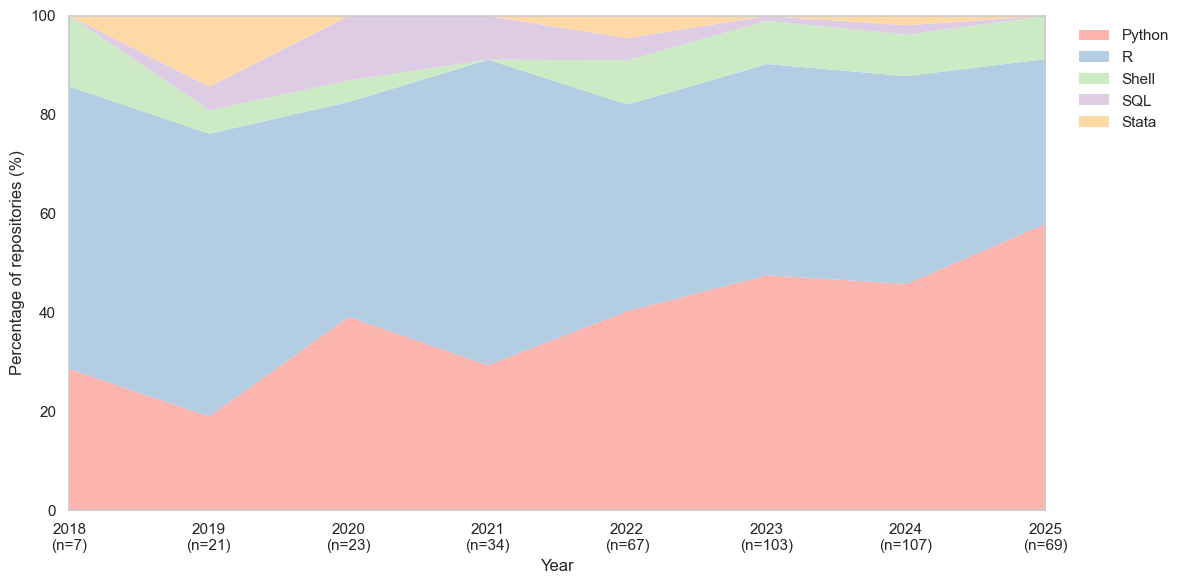

In [32]:
# ----------------------------
# 1) Canonicalize + normalize
# ----------------------------
CANONICAL = {
    "bash": "shell",
    "sh": "shell",
    "shell or bash": "shell",
    "c++": "cpp",
    "c/c++ headers": "cpp",
    "r markdown": "rmarkdown",
    "rmd": "rmarkdown",
    "jupyter": "jupyter notebook",
    "jupyter-notebook": "jupyter notebook",
    "ipynb": "jupyter notebook",
    "docker": "dockerfile",
}
NOTEBOOKS = {"jupyter notebook", "rmarkdown", "quarto"}

KEEP = ["python", "r", "shell", "sql", "matlab", "cpp", "c", "stata", "sas", "julia", "ruby", "perl"]
KEEP_SET = set(KEEP)

def normalize_lang(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return None
    s = str(x).strip().lower()
    if not s:
        return None
    s = CANONICAL.get(s, s)
    if s in NOTEBOOKS:
        return None
    if s not in KEEP_SET:
        return None
    return s


# ----------------------------
# 2) Build year from df_inscope (PMID -> year)
# ----------------------------
df_year = df_inscope.copy()
df_year["Create Date"] = pd.to_datetime(df_year["Create Date"], format="%Y/%m/%d", errors="coerce")
df_year["year"] = df_year["Create Date"].dt.year

df_year = (
    df_year.loc[df_year["year"].notna(), ["PMID", "year"]]
    .dropna(subset=["PMID"])
    .drop_duplicates(subset=["PMID"])
)

# ----------------------------
# 3) Join year into repo assessment using PMID
# ----------------------------
df = df_repo_assessment.copy()
df["PMID"] = df["PMID"].astype(str)
df_year["PMID"] = df_year["PMID"].astype(str)

df = df.merge(df_year, on="PMID", how="inner")


# ----------------------------
# 4) Explode languages and build year x language table
# ----------------------------
lang_long = (
    df[["year", "coding_languages"]]
    .dropna(subset=["coding_languages"])
    .explode("coding_languages")
)

lang_long["language"] = lang_long["coding_languages"].map(normalize_lang)
lang_long = lang_long.dropna(subset=["language"])

counts = (
    lang_long.groupby(["year", "language"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

counts = counts.reindex(columns=KEEP, fill_value=0)

# ----------------------------
# 4b) Filter to languages present in > 5 repos (overall)
# ----------------------------
MIN_REPOS = 5
lang_totals = counts.sum(axis=0)
keep_present = lang_totals[lang_totals > MIN_REPOS].index.tolist()
counts = counts[keep_present]

# distribution (share) per year across ONLY remaining languages
row_totals = counts.sum(axis=1)
shares = counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0)

# convert to percent
shares_pct = shares * 100
# only two repos in 2016
shares_pct = shares_pct.drop(index=2016)


# ----------------------------
# 5) Plot: distribution over years (stacked area) — Pastel1, 0–100%
# ----------------------------
base = list(plt.get_cmap("Pastel1").colors)
colors = [base[i % len(base)] for i in range(shares_pct.shape[1])]

years = shares_pct.index.astype(int).to_numpy()
n_by_year = row_totals.reindex(shares_pct.index).fillna(0).astype(int).to_numpy()

DISPLAY = {
    "python": "Python",
    "r": "R",
    "shell": "Shell",
    "sql": "SQL",
    "stata": "Stata",
    "sas": "SAS",
    "cpp": "C++",
    "c": "C",
    "matlab": "MATLAB",
    "julia": "Julia",
    "ruby": "Ruby",
    "perl": "Perl",
}

plt.figure(figsize=(12, 6))
plt.stackplot(
    years,
    [shares_pct[c].values for c in shares_pct.columns],
    labels=[DISPLAY.get(c, c) for c in shares_pct.columns],
    colors=colors,
    linewidth=0,
)

plt.ylim(0, 100)
plt.ylabel("Percentage of repositories (%)")
plt.xlabel("Year")

# ---- add (n=) below each year, INCLUDING years with n=0, without changing the data ----
years_present = shares_pct.index.astype(int).to_numpy()

# Full tick range you want displayed (e.g., includes 2015/2017)
years_full = np.arange(years_present.min(), years_present.max() + 1)

# n per year for labeling: use row_totals, but fill missing years with 0
n_full = (
    row_totals.reindex(years_full)
    .fillna(0)
    .astype(int)
    .to_numpy()
)

plt.xlim(years_full.min(), years_full.max())
plt.xticks(
    years_full,
    [f"{y}\n(n={n})" for y, n in zip(years_full, n_full)]
)

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)
plt.tight_layout()
plt.savefig("../figures/figure7_language_distrib.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
shares_pct

language,python,r,shell,sql,stata
year,,,,,
2018,28.571429,57.142857,14.285714,0.000000,0.000000
2019,19.047619,57.142857,4.761905,4.761905,14.285714
2020,39.130435,43.478261,4.347826,13.043478,0.000000
2021,29.411765,61.764706,0.000000,8.823529,0.000000
2022,40.298507,41.791045,8.955224,4.477612,4.477612
2023,47.572816,42.718447,8.737864,0.970874,0.000000
2024,45.794393,42.056075,8.411215,1.869159,1.869159
2025,57.971014,33.333333,8.695652,0.000000,0.000000
